In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
np.random.seed(42)

In [3]:
# -----------------------------
# 1. Confidence Interval for Mean (Gaussian)
# -----------------------------
n = 50
true_mu = 5
sigma = 2

data = np.random.normal(true_mu, sigma, size=n)

sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)

# 95% CI using t-distribution (unknown variance)
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)

ci_lower = sample_mean - t_crit * sample_std / np.sqrt(n)
ci_upper = sample_mean + t_crit * sample_std / np.sqrt(n)

print("Mean estimate:", sample_mean)
print("95% CI for mean:", (ci_lower, ci_upper))

Mean estimate: 4.54905218948772
95% CI for mean: (np.float64(4.0183607257163025), np.float64(5.079743653259138))


In [4]:
# -----------------------------
# 2. Confidence Interval for Proportion (Binomial)
# -----------------------------
n = 100
true_p = 0.6

data = np.random.binomial(1, true_p, size=n)
p_hat = np.mean(data)

# Normal approximation CI
z_crit = stats.norm.ppf(1 - alpha/2)

ci_lower = p_hat - z_crit * np.sqrt(p_hat * (1 - p_hat) / n)
ci_upper = p_hat + z_crit * np.sqrt(p_hat * (1 - p_hat) / n)

print("\nProportion estimate:", p_hat)
print("95% CI for proportion:", (ci_lower, ci_upper))


Proportion estimate: 0.59
95% CI for proportion: (np.float64(0.49360244356178373), np.float64(0.6863975564382162))



Bootstrap CI for mean: (np.float64(4.463521175019109), np.float64(5.413075591801028))


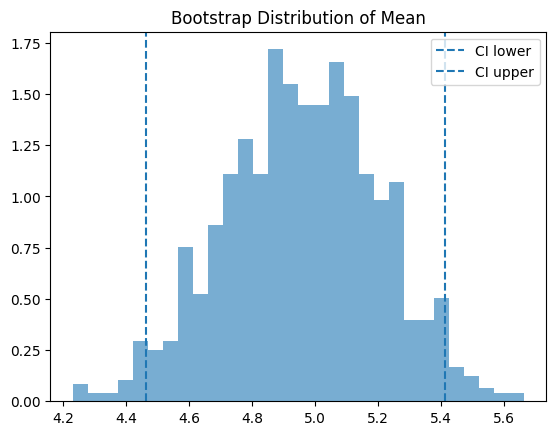

In [5]:
# -----------------------------
# 3. Bootstrap Confidence Interval
# -----------------------------
def bootstrap_ci(data, n_boot=1000, alpha=0.05):
    estimates = []
    n = len(data)
    
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        estimates.append(np.mean(sample))
    
    lower = np.percentile(estimates, 100 * alpha/2)
    upper = np.percentile(estimates, 100 * (1 - alpha/2))
    
    return lower, upper, estimates

data = np.random.normal(5, 2, size=50)

ci_lower, ci_upper, estimates = bootstrap_ci(data)

print("\nBootstrap CI for mean:", (ci_lower, ci_upper))

# Plot bootstrap distribution
plt.hist(estimates, bins=30, density=True, alpha=0.6)
plt.axvline(ci_lower, linestyle="--", label="CI lower")
plt.axvline(ci_upper, linestyle="--", label="CI upper")
plt.title("Bootstrap Distribution of Mean")
plt.legend()
plt.show()

In [6]:
for n in [10, 50, 200]:
    data = np.random.normal(5, 2, size=n)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=std/np.sqrt(n))
    print(f"n={n}, CI={ci}")

n=10, CI=(np.float64(3.183368969588444), np.float64(6.132689453949582))
n=50, CI=(np.float64(4.664533659393311), np.float64(5.761103401582479))
n=200, CI=(np.float64(4.962789603867941), np.float64(5.498363442991348))


Confidence intervals are about repeated experiments.
Bayesian intervals (MAP/posterior) are about probability of parameters.

In [7]:
# True distribution parameters
true_mu = 0
sigma = 1

# Experiment settings
n = 30          # sample size
n_exp = 100     # number of repeated experiments
alpha = 0.05

In [8]:
def compute_confidence_intervals(true_mu, sigma, n, n_exp, alpha):
  intervals = []
  contains_true = []

  for i in range(n_exp):
    # Generate sample
    data = np.random.normal(true_mu, sigma, size=n)

    # Compute CI
    sample_mean = np.mean(data)
    sample_std = np.std(data, ddof=1)
    
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    margin = t_crit * sample_std / np.sqrt(n)
    
    lower = sample_mean - margin
    upper = sample_mean + margin
    
    intervals.append((lower, upper))
    contains_true.append(lower <= true_mu <= upper)

  # -----------------------------
  # Plot
  # -----------------------------
  plt.figure(figsize=(8, 6))

  for i, ((low, high), contains) in enumerate(zip(intervals, contains_true)):
      color = "green" if contains else "red"
      plt.plot([low, high], [i, i], color=color)
      plt.plot((low + high)/2, i, 'o', color=color)

  # True mean line
  plt.axvline(true_mu, linestyle="--", label="True mean")

  plt.xlabel("Confidence Interval")
  plt.ylabel("Experiment index")
  plt.title("95% Confidence Interval Coverage")
  plt.legend()
  plt.show()

  # -----------------------------
  # Coverage result
  # -----------------------------
  coverage = np.mean(contains_true)
  print(f"Proportion of intervals containing true mean: {coverage:.2f}")

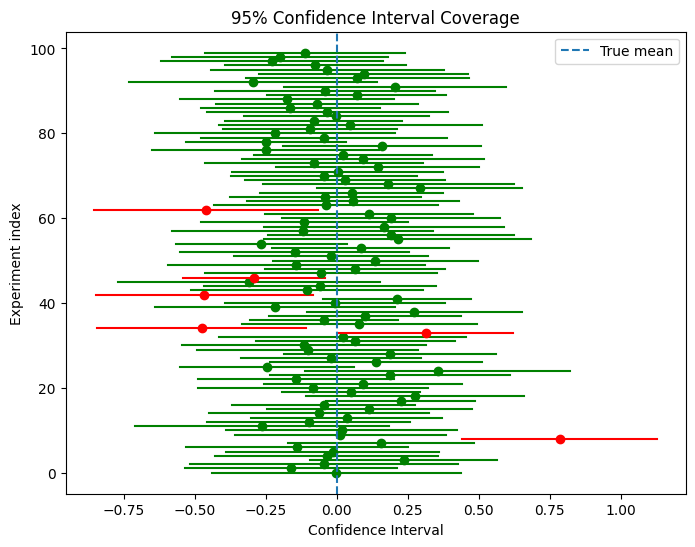

Proportion of intervals containing true mean: 0.94


In [9]:
compute_confidence_intervals(true_mu, sigma, n, n_exp, alpha)

- Each horizontal line = one experiment
- Green = interval contains true mean
- Red = interval misses it
- Vertical dashed line = true parameter

The parameter is fixed. The intervals are random.

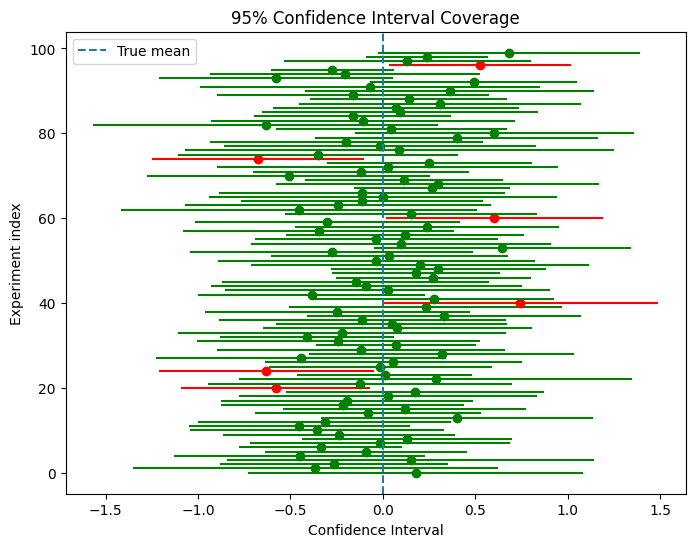

Proportion of intervals containing true mean: 0.94


In [10]:
n = 10
compute_confidence_intervals(true_mu, sigma, n, n_exp, alpha)

Intervals get wider, more variability

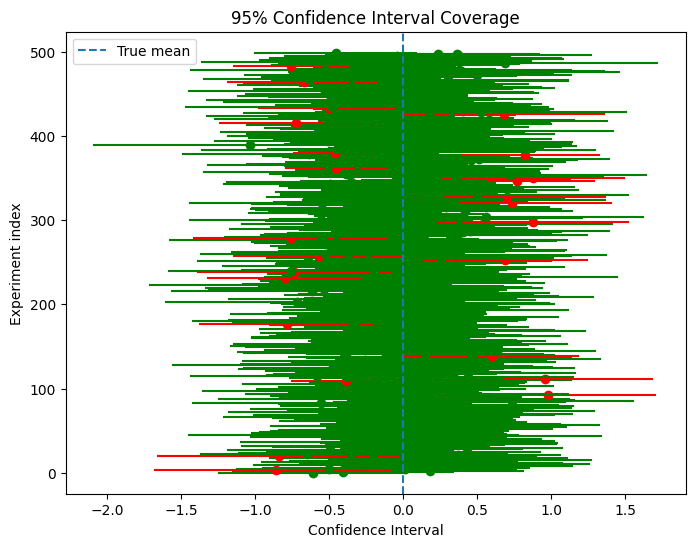

Proportion of intervals containing true mean: 0.95


In [11]:
n_exp = 500
compute_confidence_intervals(true_mu, sigma, n, n_exp, alpha)

Coverage stabilizes near 0.95

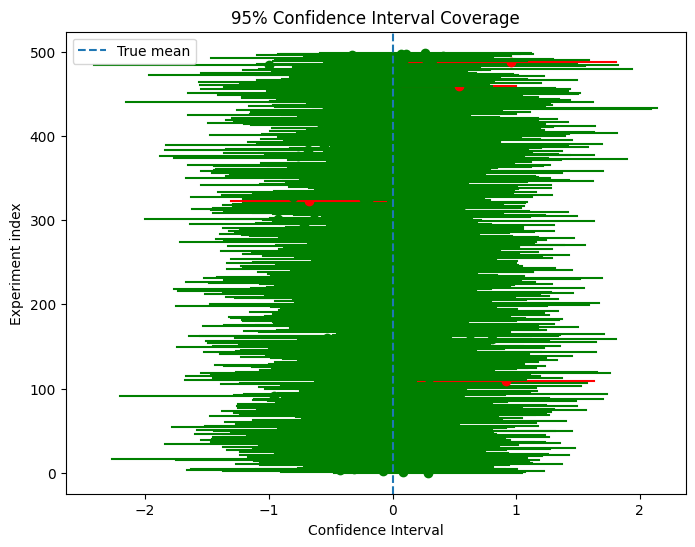

Proportion of intervals containing true mean: 0.99


In [12]:
alpha = 0.01  # 99% CI
compute_confidence_intervals(true_mu, sigma, n, n_exp, alpha)

Fewer red intervals

Frequentist CIs talk about repeated experiments.
Bayesian methods talk about probability of the parameter itself.